# FLUJO 1 — Datos reales (caudal)
- Cargo y filtro los datos reales (Fecha ≥ FECHA_INICIO)
- Analizo la data
- Construyo la data que le pasaré al modelo

# 1. Imports y rutas

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
from datetime import datetime
import time
import pickle

# Modulos de simulacion
from model_psbp_fd.pipelines import (
    # --- Esquema lineal FAR(1) ---
    FunctionalDomain,
    FARSimulator,
    gaussian_integral_kernel,
    build_integral_matrix,
    # --- Esquema no lineal FAR(p) ---
    build_lag_operators,
    companion_spectral_radius,
    NonlinearFARMap,
    ThresholdFAR,
    PointwiseNonlinearFAR,
    BilinearFAR,
    MixtureStateFAR,
    NonlinearFARSimulator,
)
# Estandarizador data 
from model_psbp_fd.functions_models import DataStandardizer

# Modulos de representacion funcional 
from model_psbp_fd.functions_models import FunctionalRepresentation

# Modulos de utilidades
from model_psbp_fd.utils import get_project_root

# Módulos de visualización 
SYS_PATH_GRAPHICS = Path("graphics")
if str(SYS_PATH_GRAPHICS) not in sys.path:
    sys.path.insert(0, str(SYS_PATH_GRAPHICS))

from model_psbp_fd.graphics import (
    # viz_traces
    plot_traces_bj, plot_traces_pj,
    plot_convergence_bj, plot_convergence_pj,
    # viz_global_components
    plot_global_components, plot_active_clusters,
    # viz_functional_data
    plot_empirical_sample, plot_functional_mean,
    plot_functional_variance, plot_mean_and_variance,
    # viz_time_series
    plot_fts_empirical, plot_fts_functional, plot_fts_comparison,
    # viz_prediction
    plot_scatter_theta, plot_functional_comparison,
    # viz_preprocessing
    plot_diagnostico_estandarizacion, plot_seleccion_basis,
    # viz_fpca
    plot_fpca_scree, plot_fpca_correlacion_lag0, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

## 1.1 Constantes a modificar según experimento 

In [66]:
# Buscamos la raiz del proyecto
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT : {PROJECT_ROOT}")


# IDENTIFICAR EL EXPERIMENTO: variables globales y rutas de salida
BASENAME      = "datos_nivel"   # ← modela NIVEL; usar el MISMO BASENAME en psbp_fd_iteracion.m y 03_03
TT            = 3
SEED          = 412389
EXPERIMENT_ID = f"{BASENAME}_{TT}"      # Nombre del experimento 
print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Seed (base)   : {SEED}")

# ── Filtro temporal ──────────────────────────────────────────────────────────
# Ventana: los primeros N_DIAS días desde FECHA_INICIO (inclusive).
# 2024 es bisiesto ⇒ 88 días = 2024-01-01 … 2024-03-28.
FECHA_INICIO = "2024-01-01"
N_DIAS       = 88
print(f"Fecha inicio  : {FECHA_INICIO}")
print(f"Ventana       : primeros {N_DIAS} días")

PROJECT_ROOT : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
Experiment ID : datos_nivel_3
Seed (base)   : 412389
Fecha inicio  : 2024-01-01
Ventana       : primeros 88 días


## 1.2 Construccion de Rutas

In [67]:
# Construccion de rutas 
_REPORT_DIR = PROJECT_ROOT / "reports" / "reales" / EXPERIMENT_ID
_ARTEFACT_DIR = PROJECT_ROOT / "artefact" / "reales" / EXPERIMENT_ID

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "reales" / "raw" / EXPERIMENT_ID,                         # Datos: raw + estandarizados
    "functional":   PROJECT_ROOT / "data" / "reales" / "processed" / "functional" / EXPERIMENT_ID,    # Coeficientes funcionales + FPCA
    "predict":      PROJECT_ROOT / "data" / "reales" / "processed" / "predict" / EXPERIMENT_ID,       # Datos predichos
    "out_report":   _REPORT_DIR,          # Figuras + métricas/config JSON
    "out_artefact": _ARTEFACT_DIR,        # Artefactos (serializados, por experimento)
}
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  {name:10s} → {path}")

  raw        → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\datos_nivel_3
  functional → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\datos_nivel_3
  predict    → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\predict\datos_nivel_3
  out_report → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\datos_nivel_3
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\datos_nivel_3


## 1.3 Lectura de archivo

In [68]:
# Define la ruta de tu archivo Excel (.xlsx)
archivo_excel = r'C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\Tabla_de_Mediciones_Wed_Jun_17_2026.xlsx'

# Nombres de las columnas limpios basados en tu estructura
nombres_columnas = ['Fecha', 'Nivel de Agua (m)', 'Turbiedad (NTU)', 'Pptacion Inst (mm)', 'Caudal (m3/seg)']

# Leer el archivo con pandas usando read_excel
df = pd.read_excel(
    archivo_excel,
    skiprows=6,             # Nos saltamos las primeras 6 filas de metadatos
    names=nombres_columnas, # Asignamos nuestros propios nombres de columnas
    header=None,            # Es importante para que no consuma la primera fila de datos reales como encabezado
    parse_dates=['Fecha']   # Intenta transformar la columna Fecha al formato adecuado
)

# Mostrar las primeras 5 filas para verificar
display(df.head())

C:\Users\56jua\AppData\Local\Temp\ipykernel_51540\3884992648.py:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_excel(


,Fecha,Nivel de Agua (m),Turbiedad (NTU),Pptacion Inst (mm),Caudal (m3/seg)
0,2026-05-31 23:44:00,1.04,NaN,0.0,1.017
1,2026-05-31 23:14:00,1.04,NaN,0.0,1.017
2,2026-05-31 22:44:00,1.04,NaN,0.0,1.017
3,2026-05-31 22:14:00,1.04,NaN,0.0,1.017
4,2026-05-31 21:44:00,1.04,NaN,0.0,1.017


# 2. DATOS

Ventana modelada [2024-01-01, 2024-03-28] = 88 días  (+1 día-ancla 2023-12-31) : filas 106162 → 4229
Filas-día cargadas (incl. día-ancla): 89
Descartados (día-ancla + vacíos) 'Nivel de Agua': 1
Descartados (día-ancla + vacíos) 'Caudal': 1
Días modelados finales (T): 88

✓ domain_grid.npy (49,) y X_curves.npy (88, 49) → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\datos_nivel_3


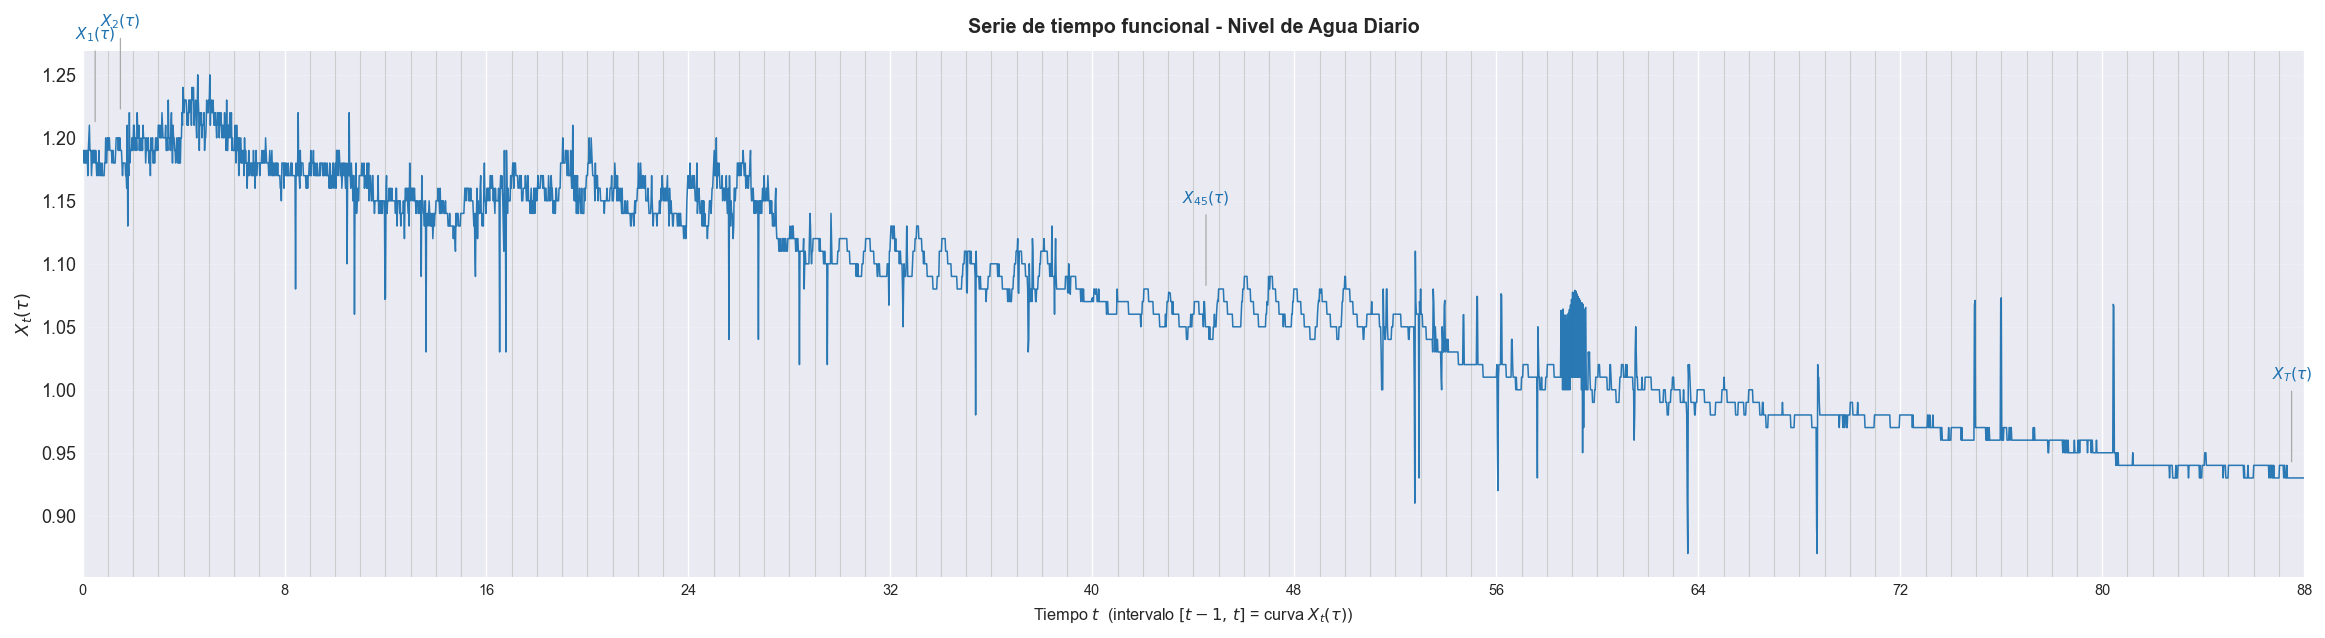

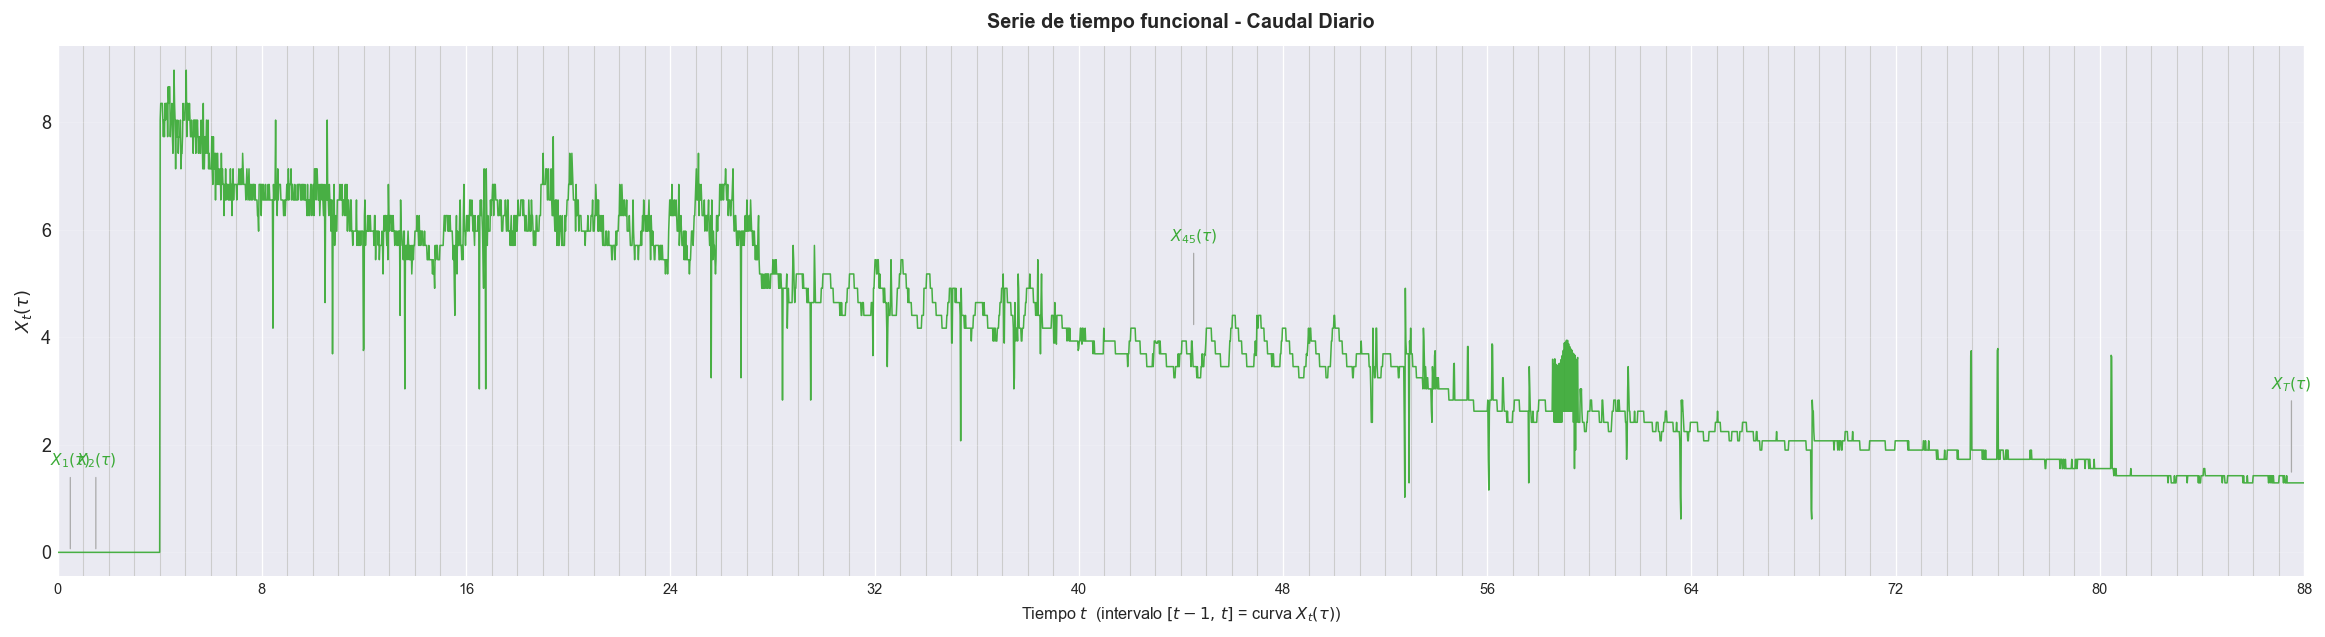

In [69]:
# ── Filtro temporal: N_DIAS días desde FECHA_INICIO + 1 día-ancla previo ─────
# Se carga un día extra ANTES de la ventana (FECHA_INICIO − 1) cuya única función
# es anclar el primer día modelado; luego se descarta como curva. Así el primer
# día (FECHA_INICIO) también recibe la corrección de continuidad en t=0.
_fecha_inicio = pd.Timestamp(FECHA_INICIO)
_fecha_fin    = _fecha_inicio + pd.Timedelta(days=N_DIAS)       # límite superior exclusivo
_fecha_buffer = _fecha_inicio - pd.Timedelta(days=1)           # día-ancla (no se modela)
_n_antes      = len(df)
df            = df.loc[(df["Fecha"] >= _fecha_buffer) & (df["Fecha"] < _fecha_fin)].copy()
print(f"Ventana modelada [{_fecha_inicio.date()}, {(_fecha_fin - pd.Timedelta(days=1)).date()}] "
      f"= {N_DIAS} días  (+1 día-ancla {_fecha_buffer.date()}) : filas {_n_antes} → {len(df)}")

# Extraemos la fecha (para agrupar por día) y la hora (para la grilla intra-diaria)
df['Dia'] = df['Fecha'].dt.date
df['Hora'] = df['Fecha'].dt.time

# Creamos matrices pivote: Filas = Días, Columnas = Horas (G=48)
matriz_nivel = df.pivot(index='Dia', columns='Hora', values='Nivel de Agua (m)')
matriz_caudal = df.pivot(index='Dia', columns='Hora', values='Caudal (m3/seg)')

# Total de filas-día cargadas (incluye el día-ancla previo)
dias_originales_nivel = len(matriz_nivel)
dias_originales_caudal = len(matriz_caudal)

# ---------------------------------------------------------
# Red de seguridad para huecos aislados: con 48 mediciones/día la matriz está
# casi completa, así que fillna(media_hora) actúa sobre pocos NaN sueltos.
# ---------------------------------------------------------
matriz_nivel = matriz_nivel.fillna(matriz_nivel.mean())
matriz_caudal = matriz_caudal.fillna(matriz_caudal.mean())

# Eliminamos SOLO los días que estén 100% vacíos
matriz_nivel = matriz_nivel.dropna()
matriz_caudal = matriz_caudal.dropna()

# ── Ancla de continuidad: última observación del día anterior en t=0 ──────────
# Cada curva del día d gana un punto en la posición 0 = última medición del día
# d−1 (columna final de la fila previa). La PRIMERA fila de la matriz es el
# día-ancla previo (FECHA_INICIO − 1): su ancla es NaN y se descarta. Con esto
# TODOS los días modelados —incluido el primero (FECHA_INICIO)— quedan anclados.
# La grilla pasa de G a G+1 puntos; el resto del pipeline la hereda sin cambios.
anchor_nivel  = matriz_nivel.iloc[:, -1].shift(1)
anchor_caudal = matriz_caudal.iloc[:, -1].shift(1)

matriz_nivel.insert(0, "t0_prev", anchor_nivel)
matriz_caudal.insert(0, "t0_prev", anchor_caudal)

matriz_nivel  = matriz_nivel.iloc[1:]    # descartar día-ancla previo (FECHA_INICIO − 1)
matriz_caudal = matriz_caudal.iloc[1:]

# Descartados: el día-ancla previo (por diseño) + días 100% vacíos
dias_omitidos_nivel = dias_originales_nivel - len(matriz_nivel)
dias_omitidos_caudal = dias_originales_caudal - len(matriz_caudal)

print(f"Filas-día cargadas (incl. día-ancla): {dias_originales_nivel}")
print(f"Descartados (día-ancla + vacíos) 'Nivel de Agua': {dias_omitidos_nivel}")
print(f"Descartados (día-ancla + vacíos) 'Caudal': {dias_omitidos_caudal}")
print(f"Días modelados finales (T): {len(matriz_caudal)}\n")

# Convertimos a arrays numpy con forma (T, G+1)  ← col 0 = ancla, cols 1..G = día
X_nivel = matriz_nivel.values
X_caudal = matriz_caudal.values

# Grilla normalizada del dominio: G+1 puntos (ancla en t=0, día en t=1/G … 1)
G = X_nivel.shape[1]
grid = np.linspace(0, 1, G)

# ── Persistencia de insumos funcionales (los consume 03_03) ──────────────────
# [FIX contrato] 03_03 carga domain_grid.npy y X_curves.npy desde 'functional'.
np.save(PATHS["functional"] / "domain_grid.npy", grid)
np.save(PATHS["functional"] / "X_curves.npy",    X_nivel)
print(f"✓ domain_grid.npy {grid.shape} y X_curves.npy {X_nivel.shape} → {PATHS['functional']}")

# Gráfica para Nivel de Agua
fig_nivel = plot_fts_empirical(
    X=X_nivel,
    grid=grid,
    color="#1a6faf", # Azul
    title="Serie de tiempo funcional - Nivel de Agua Diario",
    figsize=(18, 5)  ,
    save_path  = str(PATHS["out_report"] / "02_Nivel de Agua Diario_raw.png")
)
plt.show()

# Gráfica para Caudal
fig_caudal = plot_fts_empirical(
    X=X_caudal,
    grid=grid,
    color="#3aaa35", # Verde para diferenciar
    title="Serie de tiempo funcional - Caudal Diario",
    figsize=(18, 5),
    save_path  = str(PATHS["out_report"] / "02_Caudal Diario_raw.png")
)
plt.show()

In [70]:
# Construimos el diccionario con la estructura esperada por tu pipeline
data_reales = {
    "grid": grid,          # Array numpy (G,)
    "X_nivel": X_nivel,    # Matriz numpy (T, G)
    "X_caudal": X_caudal,  # Matriz numpy (T, G)
    "dias": matriz_caudal.index.values, # Guardamos las fechas de los días por si se necesitan
    "metadata": {
        "descripcion": "Datos reales de estación hidrológica corregidos por promedio de hora",
        "fecha_procesamiento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "fecha_inicio": FECHA_INICIO,
        "T": len(matriz_caudal),
        "G": G
    }
}

filepath_dataset = Path(PATHS['raw']) / f"{EXPERIMENT_ID}_dataset_procesado.pkl"

# Guardamos el objeto usando pickle
with open(filepath_dataset, "wb") as f:
    pickle.dump(data_reales, f)

print(f"✓ Dataset real persistido exitosamente en: {filepath_dataset}")
print(f"  - Componentes: 'grid' {grid.shape}, 'X_nivel' {X_nivel.shape}, 'X_caudal' {X_caudal.shape}")

✓ Dataset real persistido exitosamente en: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\datos_nivel_3\datos_nivel_3_dataset_procesado.pkl
  - Componentes: 'grid' (49,), 'X_nivel' (88, 49), 'X_caudal' (88, 49)


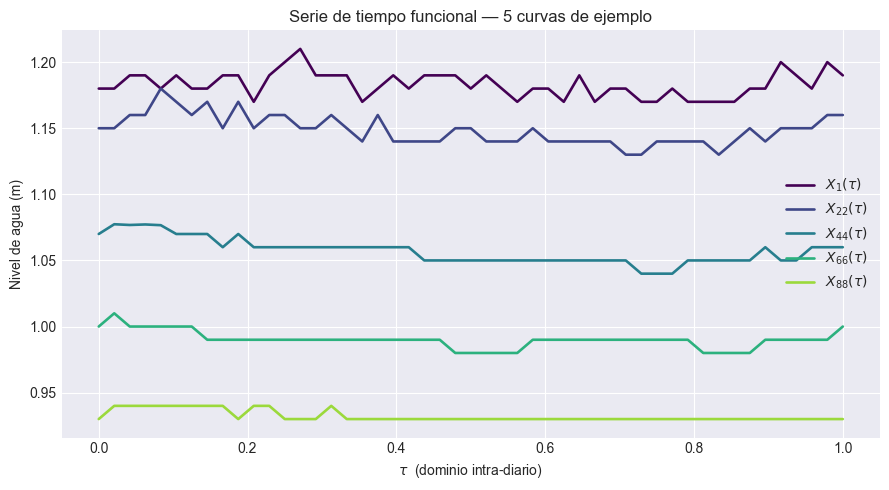

In [71]:
# ── 5 curvas de la serie funcional (nivel de agua) — para presentación ───────
import numpy as np, matplotlib.pyplot as plt

X = X_nivel                                            # serie modelada (T, G); cambia a X_caudal si aplica
idx = np.linspace(0, X.shape[0] - 1, 5).astype(int)   # 5 días equiespaciados en la ventana

fig, ax = plt.subplots(figsize=(9, 5))
for col, i in zip(plt.cm.viridis(np.linspace(0, .85, len(idx))), idx):
    ax.plot(grid, X[i], color=col, lw=1.9, label=f"$X_{{{i+1}}}(\\tau)$")

ax.set_xlabel(r"$\tau$  (dominio intra-diario)")
ax.set_ylabel("Nivel de agua (m)")
ax.set_title("Serie de tiempo funcional — 5 curvas de ejemplo")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "pres_5_curvas.png", dpi=150, bbox_inches="tight")
plt.show()

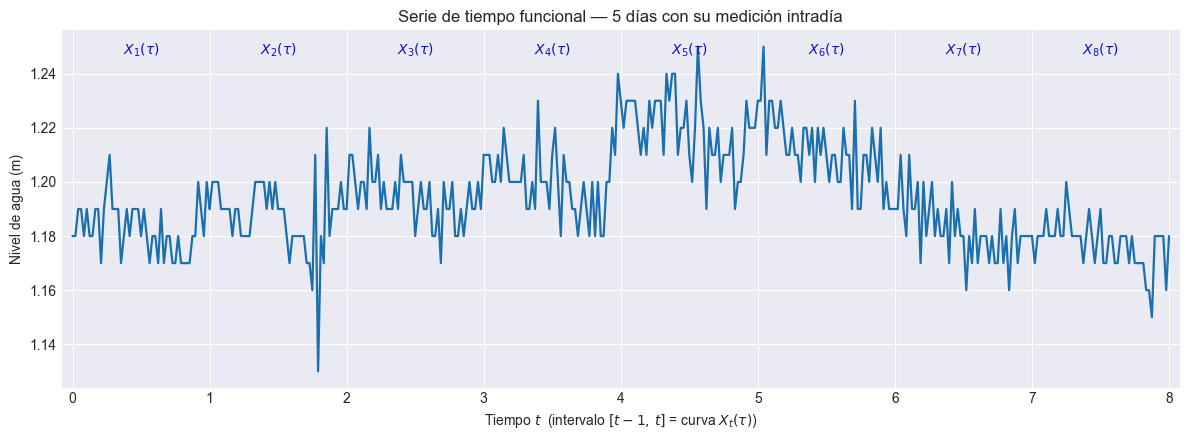

In [86]:
# ── 5 días como serie de tiempo (intradía indexado en t) — presentación ──────
import numpy as np, matplotlib.pyplot as plt

n_dias = 8
X = X_nivel                                   # serie modelada (T, G+1); cambia a X_caudal si aplica

fig, ax = plt.subplots(figsize=(12, 4.5))
for i in range(n_dias):
    ax.plot(i + grid, X[i], color="#1a6faf", lw=1.6)   # día i ocupa el intervalo [i, i+1] en t

for i in range(n_dias + 1):                             # separadores de día
    ax.axvline(i, color="0.75", lw=0.8, zorder=0)
for i in range(n_dias):                                 # etiqueta por curva
    ax.text(i + 0.5, 0.97, f"$X_{{{i+1}}}(\\tau)$",
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=10, color="#0f0fd3")

ax.set_xlabel(r"Tiempo $t$  (intervalo $[t-1,\,t]$ = curva $X_t(\tau)$)")
ax.set_ylabel("Nivel de agua (m)")
ax.set_title("Serie de tiempo funcional — 5 días con su medición intradía")
ax.set_xticks(range(n_dias + 1))
ax.margins(x=0.01)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "pres_5_series_t.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Representación funcional B-spline

In [73]:
# ---------------------------------------------------------
# SELECCIÓN DE PARÁMETROS PARA EVALUAR LA REPRESENTACIÓN FUNCIONAL 
# ---------------------------------------------------------

# Apuntamos 'X_eval' a la serie de NIVEL (serie a modelar)
X_eval = X_nivel 
T = X_eval.shape[0]

# [FIX] Criterio de menor complejidad que alcanza VAR_TARGET_BASIS
N_BASIS_RANGE    = range(2, min(30, T // 2))
ORDER_RANGE      = range(1, 5) # Partimos en 2 según tu fix para evitar orden 1 (ruidoso)
VAR_TARGET_BASIS = 0.99
selection_records = []

for order_bs in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < order_bs:
            continue
        try:
            # Instanciamos el representador funcional usando las variables corregidas
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=order_bs)
            TH_tmp = fr_tmp.fit_transform(X_eval, grid)  # Usamos 'grid' en lugar de 'domain.grid'
            X_rec  = fr_tmp.reconstruct(TH_tmp)
            
            # Métricas
            ss_res = np.sum((X_eval - X_rec) ** 2)
            ss_tot = np.sum((X_eval - X_eval.mean(axis=0, keepdims=True)) ** 2)
            vr     = 1.0 - ss_res / ss_tot
            rmse_c = np.sqrt(np.mean((X_eval - X_rec) ** 2, axis=1))
            
            selection_records.append({
                "n_basis": nb, "order": order_bs, "var_retained": vr,
                "rmse_mean": rmse_c.mean(), "rmse_max": rmse_c.max(),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={order_bs}: {e}")

sel_df = pd.DataFrame(selection_records)

# ── Criterio: menor complejidad que alcanza el umbral ─────────────────────
candidates = sel_df[sel_df["var_retained"] >= VAR_TARGET_BASIS]
if candidates.empty:
    print(f"⚠ Ningún (n_basis, order) alcanza var_retained ≥ {VAR_TARGET_BASIS:.2%}; "
          f"se usa el de mayor varianza retenida.")
    candidates = sel_df

best_row = candidates.sort_values(["n_basis", "order"], ascending=[True, True]).iloc[0]
nb_best  = int(best_row["n_basis"])
ord_best = int(best_row["order"])

# Imprimir la tabla estilizada
display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}", "rmse_max": "{:.6f}"})
    .background_gradient(subset=["var_retained"], cmap="YlGn")
    .background_gradient(subset=["rmse_mean"],    cmap="YlOrRd_r"))

print(f"\nRecomendación (menor n_basis con var ≥ {VAR_TARGET_BASIS:.0%}): "
      f"n_basis={nb_best}, order={ord_best}, var_retained={best_row['var_retained']:.4%}")

,n_basis,order,var_retained,rmse_mean,rmse_max
0,2,1,97.5796%,0.011261,0.030421
1,3,1,97.7470%,0.010713,0.029372
2,4,1,97.8883%,0.010293,0.029354
3,5,1,98.0381%,0.009767,0.028915
4,6,1,98.0896%,0.009560,0.029300
5,7,1,98.2039%,0.009179,0.029094
6,8,1,98.2622%,0.009003,0.028992
7,9,1,98.3236%,0.008774,0.028214
8,10,1,98.4308%,0.008451,0.028028
9,11,1,98.4268%,0.008454,0.028363



Recomendación (menor n_basis con var ≥ 99%): n_basis=22, order=2, var_retained=99.0543%


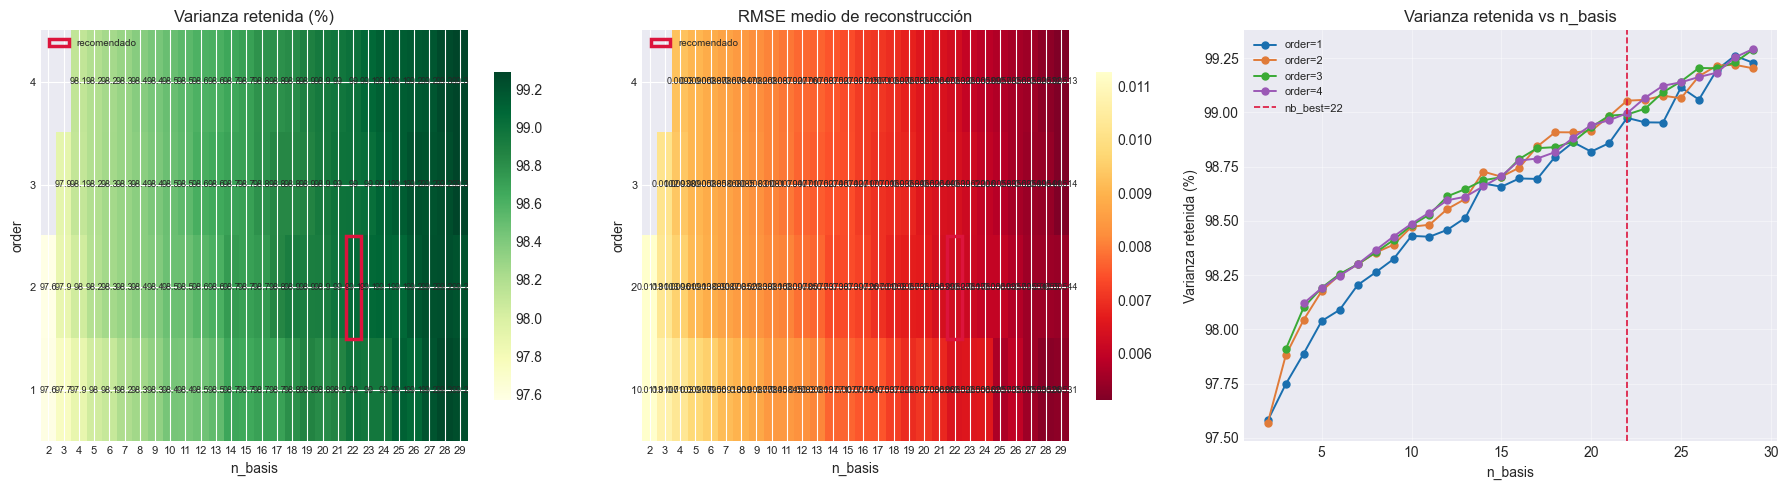

In [74]:
# ── Heatmaps + curva de varianza retenida ────────────────────────────────────
fig = plot_seleccion_basis(
    sel_df, nb_best, ord_best,
    save_path=str(PATHS["out_report"] / "08_seleccion_basis.png"),
)
plt.show()

## 3.1 Ajuste y visualización de la representación funcional

Representación B-spline: n_basis=22, order=1
THETA shape: (88, 22)  (T=88, K=22)


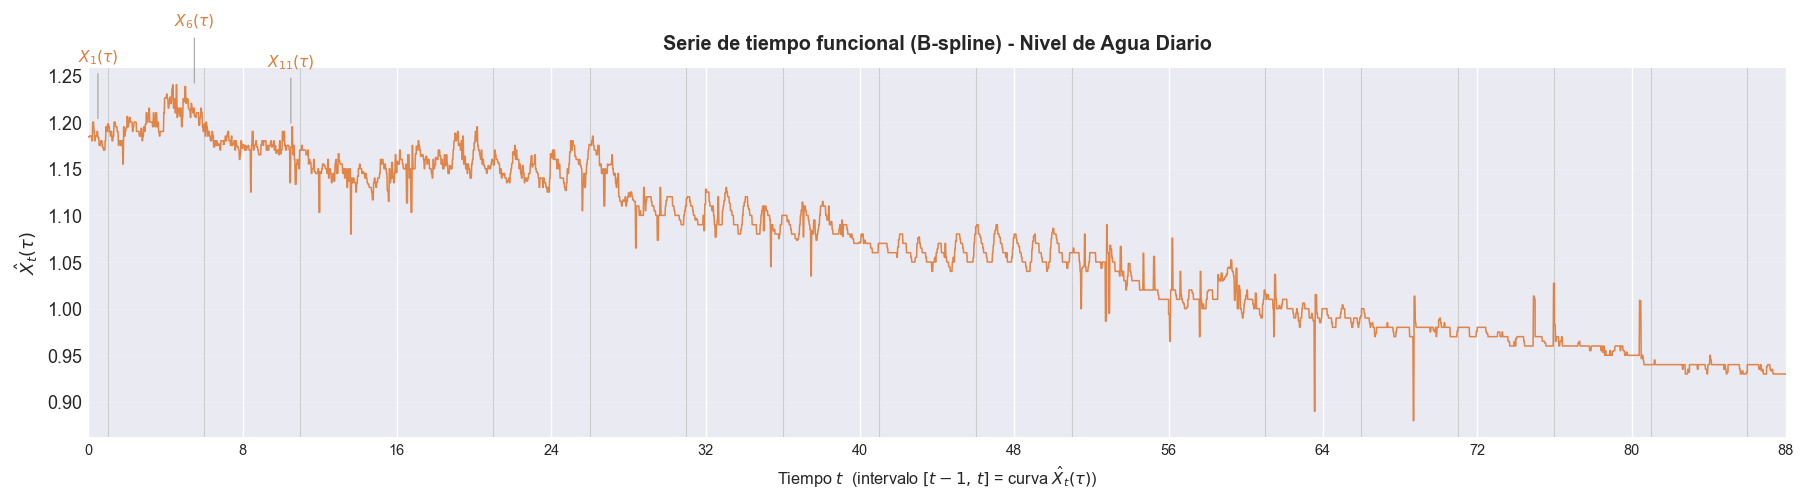

✓ [functional] functional_representation.pkl  → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\datos_nivel_3
✓ [functional] fr_config.json                 → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\datos_nivel_3


In [75]:
# ── Parámetros de la representación funcional ────────────────────────────────
# [FIX] Por defecto se usa la selección automática de §3 (nb_best, ord_best),
# eliminando el hardcode n_basis=12 que ignoraba el criterio VAR_TARGET_BASIS.
# Para fijar manualmente, sobreescribe con enteros, p.ej.:
#     N_BASIS_FINAL = 12 ; ORDER_FINAL = 3
N_BASIS_FINAL = 22
ORDER_FINAL   = 1
print(f"Representación B-spline: n_basis={N_BASIS_FINAL}, order={ORDER_FINAL}")

fr = FunctionalRepresentation(method="bspline", n_basis=N_BASIS_FINAL, order=ORDER_FINAL)

# Ajuste (sobre NIVEL de agua, con ancla del día previo en t=0)
THETA = fr.fit_transform(X_nivel, grid)
print(f"THETA shape: {THETA.shape}  (T={THETA.shape[0]}, K={THETA.shape[1]})")

# ── Serie de tiempo funcional con representación B-spline ────────────────────
T_total = X_nivel.shape[0]
highlight_idx = [0, min(5, T_total - 1), min(10, T_total - 1)]

fig = plot_fts_functional(
    X_nivel, 
    grid,
    fr              = fr,
    highlight_idx   = highlight_idx,
    title           = f"Serie de tiempo funcional (B-spline) - Nivel de Agua Diario",
    separator_every = 5,
    save_path       = str(PATHS["out_report"] / "09_fts_funcional_bspline_nivel.png") if "out_report" in PATHS else None
)
plt.show()

# ── Serializar FunctionalRepresentation (la usa 03_03) ───────────────────────
# [FIX contrato] 03_03 busca 'functional_representation.pkl' (sin sufijo _caudal).
fr_pkl_path = PATHS["functional"] / "functional_representation.pkl"
with open(fr_pkl_path, "wb") as _f:
    pickle.dump(fr, _f, protocol=pickle.HIGHEST_PROTOCOL)

# Config legible para referencia
fr_config = {
    "method":   fr.method if hasattr(fr, "method") else "bspline",
    "n_basis":  int(THETA.shape[1]),
    "order":    getattr(fr, "order", None),
    "T":        int(THETA.shape[0]),
    "K":        int(THETA.shape[1]),
}
with open(PATHS["functional"] / "fr_config.json", "w", encoding="utf-8") as _f:
    json.dump(fr_config, _f, indent=2, ensure_ascii=False)

print(f"✓ [functional] functional_representation.pkl  → {PATHS['functional']}")
print(f"✓ [functional] fr_config.json                 → {PATHS['functional']}")

## 3.2 Pasar la base selecionada a FPCA analizar cuantos componentes me quedare

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,6.9580e-03,98.7334%,98.7334%,+0.999
1,2,1.4617e-05,0.2074%,98.9408%,+0.620
2,3,1.3198e-05,0.1873%,99.1281%,-0.025
3,4,1.0279e-05,0.1459%,99.2739%,-0.229
4,5,8.8256e-06,0.1252%,99.3992%,+0.108
5,6,8.0856e-06,0.1147%,99.5139%,+0.083
6,7,5.5558e-06,0.0788%,99.5927%,+0.155
7,8,5.0625e-06,0.0718%,99.6646%,-0.083
8,9,4.3575e-06,0.0618%,99.7264%,-0.100
9,10,3.4478e-06,0.0489%,99.7753%,+0.201



K B-spline disponibles : 22
SUGERENCIA (var ≥ 99%) : M_SUGGERIDO = 3   ← solo referencia; fija M_FPCA en la celda correspondiente


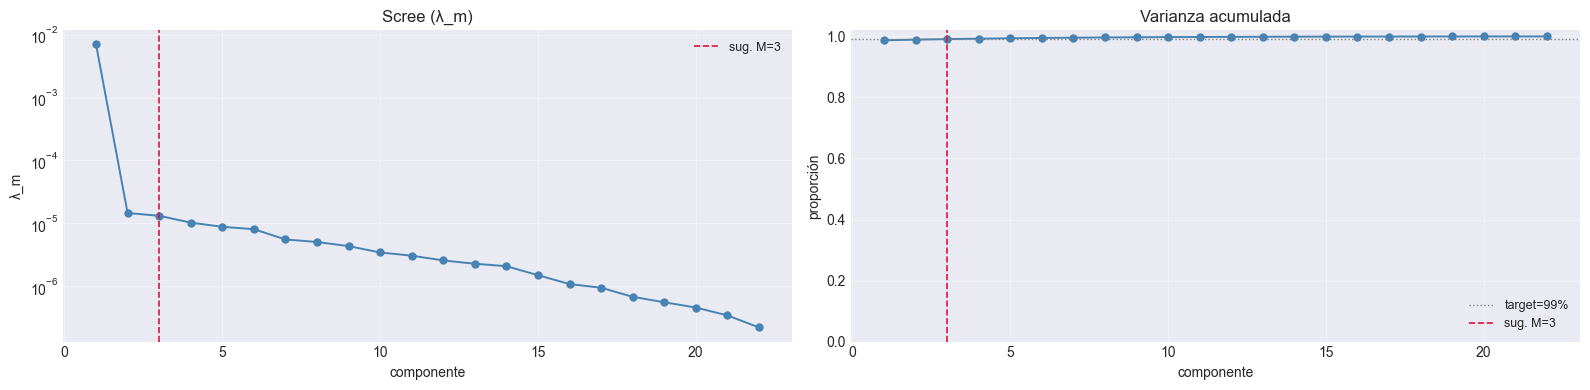

In [76]:
# ----------------------------------------------------------------------------
# ANÁLISIS DE COMPONENTES PRINCIPALES FUNCIONALES (FPCA) SOBRE B-SPLINE
# ----------------------------------------------------------------------------
# Base B-spline NO ortonormal ⇒ Gram W = <φ_j,φ_k>_{L²} ≠ I. La FPCA correcta
# diagonaliza en métrica L²:  (W^{1/2} S_θ W^{1/2}) u = λ u,  ‖ψ_m‖_{L²}=1.
# ----------------------------------------------------------------------------
K = THETA.shape[1]

# ── Base en grilla + verificación de linealidad de reconstruct ───────────────
Phi = fr.reconstruct(np.eye(K)).T                        # (G, K): columna k = φ_k en grilla
_lin_err = np.abs(fr.reconstruct(THETA) - THETA @ Phi.T).max()
assert _lin_err < 1e-8, (
    f"reconstruct no es el mapa lineal Θ·Φᵀ esperado (err={_lin_err:.2e})."
)

# ── Gram L² (cuadratura trapezoidal) ─────────────────────────────────────────
gpts = np.asarray(grid, dtype=float) # Reemplazado domain.grid por grid
w_quad = np.empty_like(gpts)
w_quad[1:-1] = (gpts[2:] - gpts[:-2]) / 2.0
w_quad[0]    = (gpts[1]  - gpts[0])  / 2.0
w_quad[-1]   = (gpts[-1] - gpts[-2]) / 2.0
W = Phi.T @ (w_quad[:, None] * Phi); W = 0.5 * (W + W.T)

# ── Covarianza de coeficientes y problema propio simetrizado en L² ───────────
mu_theta = THETA.mean(axis=0)
Theta_c  = THETA - mu_theta
S_theta  = (Theta_c.T @ Theta_c) / (THETA.shape[0] - 1)
evW, VW    = np.linalg.eigh(W); evW = np.clip(evW, 1e-12, None)
W_half     = VW @ np.diag(np.sqrt(evW))   @ VW.T
W_half_inv = VW @ np.diag(1 / np.sqrt(evW)) @ VW.T
M_sym = W_half @ S_theta @ W_half; M_sym = 0.5 * (M_sym + M_sym.T)
evals, U = np.linalg.eigh(M_sym)
ord_desc = np.argsort(evals)[::-1]   # [FIX] renombrado: 'order' sombreaba el order B-spline
evals = np.clip(evals[ord_desc], 0.0, None); U = U[:, ord_desc]
B_full = W_half_inv @ U                                  # (K, K) coef. autofunciones (b_mᵀ W b_m = 1)
var_ratio = evals / evals.sum(); var_cum = np.cumsum(var_ratio)

# ── Diagnóstico DINÁMICO: AR(1) propio de cada componente (≠ varianza) ───────
# Varianza = representación; AR(1) = dinámica. Una FPC de var. baja puede tener
# AR fuerte (útil para pronóstico) y una de var. alta puede ser ruido temporal.
SCORES_full = Theta_c @ (W @ B_full)                     # (T, K) scores de TODAS las componentes
s0, s1 = SCORES_full[:-1], SCORES_full[1:]
ar1_own = (s1 * s0).sum(0) / np.clip((s0 * s0).sum(0), 1e-12, None)   # pendiente AR(1) por comp.

# ── Sugerencia automática (SOLO referencia; no vincula nada) ─────────────────
VAR_TARGET  = 0.99
M_SUGGERIDO = int(np.clip(np.searchsorted(var_cum, VAR_TARGET) + 1, 1, K))

# ── Tabla ─────────────────────────────────────────────────────────────────────
fpca_tbl = pd.DataFrame({
    "componente": np.arange(1, K + 1),
    "autovalor":  evals,
    "var_ratio":  var_ratio,
    "var_acum":   var_cum,
    "ar1_propio": ar1_own,
})
display(fpca_tbl.head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}", "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"}
).background_gradient(subset=["var_ratio"], cmap="YlGn")
 .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))
print(f"\nK B-spline disponibles : {K}")
print(f"SUGERENCIA (var ≥ {VAR_TARGET:.0%}) : M_SUGGERIDO = {M_SUGGERIDO}   "
      f"← solo referencia; fija M_FPCA en la celda correspondiente")

# ── Scree + varianza acumulada ────────────────────────────────────────────────
fig = plot_fpca_scree(
    evals, var_cum, M_SUGGERIDO,
    var_target=VAR_TARGET,
    save_path=str(PATHS["out_report"] / "10_fpca_scree_nivel.png") if "out_report" in PATHS else None
)
plt.show()

## 3.3 Obtener el FPCA basado en la selecion

[sanidad] max|<ψ_i,ψ_j> - I| : 4.44e-16   (≈ 0)
max|media ξ|                 : 6.49e-17   (≈ 0)
max|diag(Γ0) - λ|            : 1.73e-18   (≈ 0)
max|correlación fuera diag.| : 3.15e-15   (≈ 0 ⇒ sin correlación contemporánea)


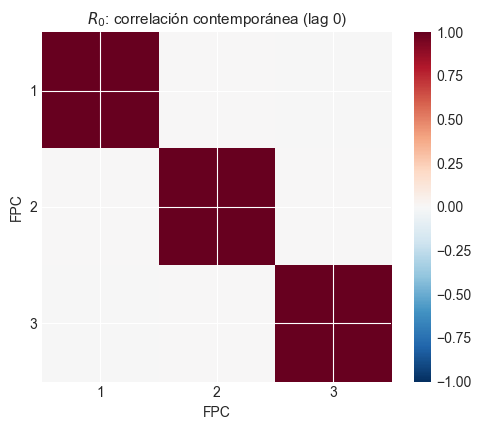


SCORES shape : (88, 3)   (T=88, M=3)


In [77]:
M_FPCA = 3   # ← nº de componentes FPCA a retener (lo fijas TÚ)

# ── Validación (no avanza hasta que elijas) ──────────────────────────────────
assert M_FPCA is not None, "Define M_FPCA (entero) en esta celda antes de continuar."
assert isinstance(M_FPCA, (int, np.integer)) and 1 <= M_FPCA <= K, (
    f"M_FPCA debe ser entero en [1, {K}]. Recibido: {M_FPCA!r}"
)
M_fpca = int(M_FPCA)                                     # alias en minúscula para el resto del notebook

# ── Construcción con el M elegido ────────────────────────────────────────────
B        = B_full[:, :M_fpca]                            # (K, M)
Psi_grid = Phi @ B                                       # (G, M) autofunciones (‖ψ_m‖_{L²}=1)
mu_grid  = Phi @ mu_theta                                # (G,)
SCORES   = Theta_c @ (W @ B)                             # (T, M) scores ξ

# ── Sanidad de construcción: autofunciones ortonormales en L² (Gram ≈ I) ─────
gram_psi = Psi_grid.T @ (w_quad[:, None] * Psi_grid)
print(f"[sanidad] max|<ψ_i,ψ_j> - I| : {np.abs(gram_psi - np.eye(M_fpca)).max():.2e}   (≈ 0)")

# EVALUACIÓN DE CORRELACIÓN  (lag 0)
Gamma0 = np.atleast_2d(np.cov(SCORES, rowvar=False, ddof=1))     # covarianza lag 0
R0     = np.atleast_2d(np.corrcoef(SCORES, rowvar=False))        # correlación lag 0
off_R0 = np.abs(R0 - np.eye(M_fpca))

print(f"max|media ξ|                 : {np.abs(SCORES.mean(0)).max():.2e}   (≈ 0)")
print(f"max|diag(Γ0) - λ|            : {np.abs(np.diag(Gamma0) - evals[:M_fpca]).max():.2e}   (≈ 0)")
print(f"max|correlación fuera diag.| : {off_R0.max():.2e}   (≈ 0 ⇒ sin correlación contemporánea)")

if M_fpca >= 2:
    fig = plot_fpca_correlacion_lag0(
        R0,
        save_path=str(PATHS["out_report"] / "11_fpca_correlacion_lag0.png"),
    )
    plt.show()

# ── Empaquetado FPCA + operador de reconstrucción (inversa de FPCA) ──────────
def reconstruct_from_scores(S_hat):
    """X̂(t) = μ(t) + Σ_m ξ_m ψ_m(t)."""
    S_hat = np.atleast_2d(np.asarray(S_hat, dtype=float))
    return mu_grid[None, :] + S_hat @ Psi_grid.T

FPCA = {
    "M": M_fpca, "eigvals": evals[:M_fpca], "mean_grid": mu_grid,
    "eigfun_grid": Psi_grid, "coef_eigfun": B, "gram": W,
    "reconstruct": reconstruct_from_scores,
}

# ── Persistencia de datos · representación funcional + FPCA → data/.../functional ──
np.savetxt(PATHS["functional"] / "theta.csv",               THETA,    delimiter=",")
np.savetxt(PATHS["functional"] / "basis_phi.csv",           Phi,      delimiter=",")
np.savetxt(PATHS["functional"] / "grid.csv",                gpts,     delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_scores.csv",         SCORES,   delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_eigenfunctions.csv", Psi_grid, delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_mean.csv",           mu_grid,  delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_gram_W.csv",      W,        delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_coef_B.csv",      B,        delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_mu_theta.csv",    mu_theta, delimiter=",")
with open(PATHS["functional"] / "fpca_meta.json", "w", encoding="utf-8") as _f:
    json.dump({"M": int(M_fpca), "K": int(THETA.shape[1]),
               "eigvals": FPCA["eigvals"].tolist(),
               "var_explained": float(var_cum[M_fpca - 1]), "var_target": VAR_TARGET},
              _f, indent=2, ensure_ascii=False)

print(f"\nSCORES shape : {SCORES.shape}   (T={SCORES.shape[0]}, M={M_fpca})")

# 4. Construcción de datasets AR(p) sobre scores de FPCA (ecuación-por-ecuación)

## 4.0 Estandarización de scores ξ  **[FIX — punto de entrada al modelo]**

Los scores FPCA tienen varianza λₘ (heterogénea entre componentes:
λ₁ ≫ λ_M). Se estandarizan por columna (z-score, ddof=0) **antes** de
construir los datasets AR(p): respuesta y covariables entran al PSBP en
escala estandarizada. El estandarizador se persiste para que `03_03`
des-estandarice las predicciones antes de reconstruir curvas.

Nota: las correlaciones de rezagos (§4.1) son invariantes a esta
transformación lineal; se calculan sobre `SCORES_STD` por consistencia.

Método: zscore_column
Features: 3
  Media:     min=-0.0000, max=0.0000
  Std:       min=0.0036, max=0.0829
SCORES_STD : shape=(88, 3)
  max|media|  = 4.35e-17  (debe ≈ 0)
  max|std-1|  = 2.22e-16  (debe ≈ 0)
  std original por componente (=√λ_m): [0.083 0.004 0.004]
✓ Standardizer guardado en: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\datos_nivel_3\scores_standardizer
[functional] fpca_scores_std.csv (88, 3) → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\datos_nivel_3


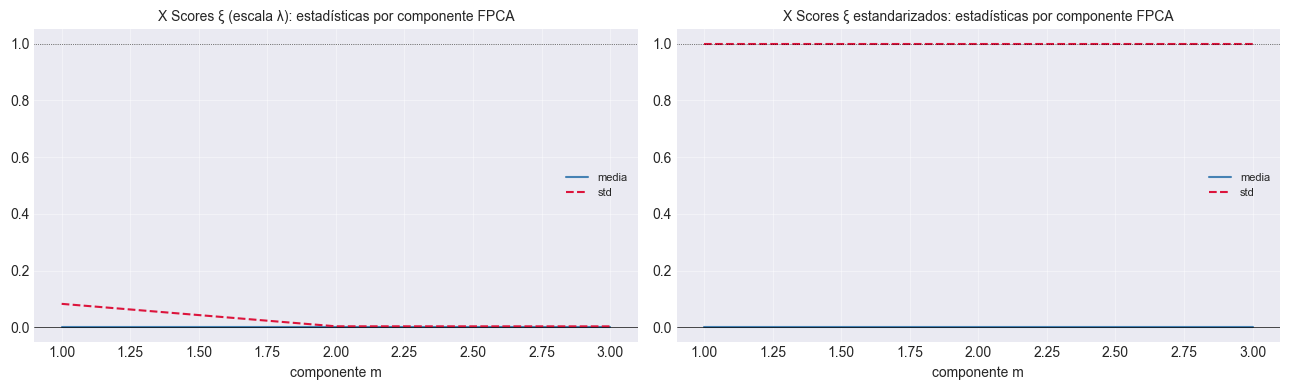

In [78]:
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
SCORES_STD = scores_standardizer.fit_transform(SCORES)

print(scores_standardizer.summary())
print(f"SCORES_STD : shape={SCORES_STD.shape}")
print(f"  max|media|  = {np.abs(SCORES_STD.mean(axis=0)).max():.2e}  (debe ≈ 0)")
print(f"  max|std-1|  = {np.abs(SCORES_STD.std(axis=0) - 1).max():.2e}  (debe ≈ 0)")
print(f"  std original por componente (=√λ_m): "
      f"{np.array2string(SCORES.std(axis=0), precision=3)}")

# ── Persistencia ─────────────────────────────────────────────────────────────
scores_standardizer.save(PATHS["functional"] / "scores_standardizer")
np.savetxt(PATHS["functional"] / "fpca_scores_std.csv", SCORES_STD, delimiter=",")
print(f"[functional] fpca_scores_std.csv {SCORES_STD.shape} → {PATHS['functional']}")

# ── Diagnóstico visual (media/std por componente, antes y después) ───────────
fig = plot_diagnostico_estandarizacion(
    SCORES, SCORES_STD, np.arange(1, M_fpca + 1),
    labels=("Scores ξ (escala λ)", "Scores ξ estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "04_diagnostico_estandarizacion_scores.png"),
)
fig.axes[0].set_xlabel("componente m"); fig.axes[1].set_xlabel("componente m")
plt.show()

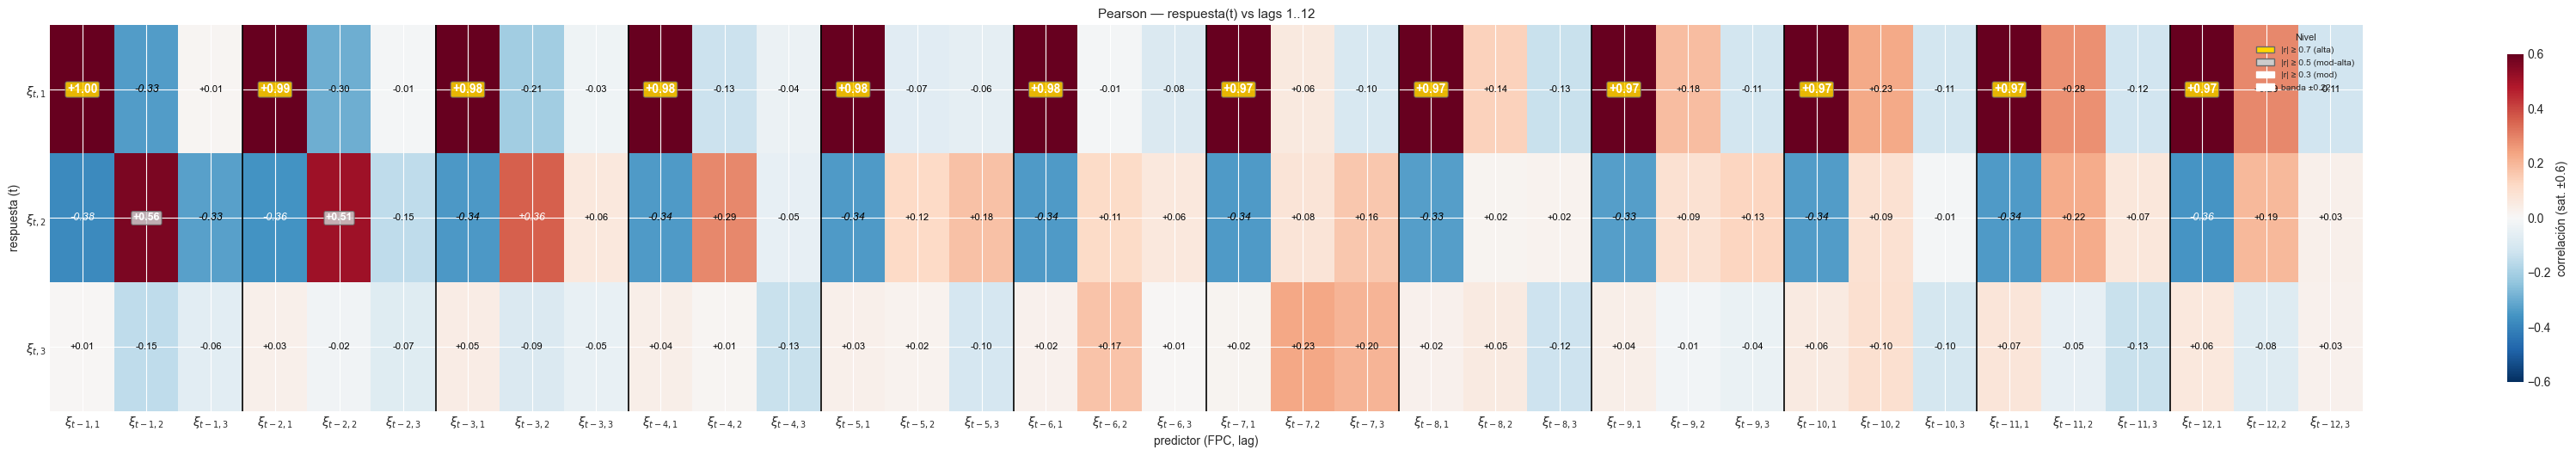

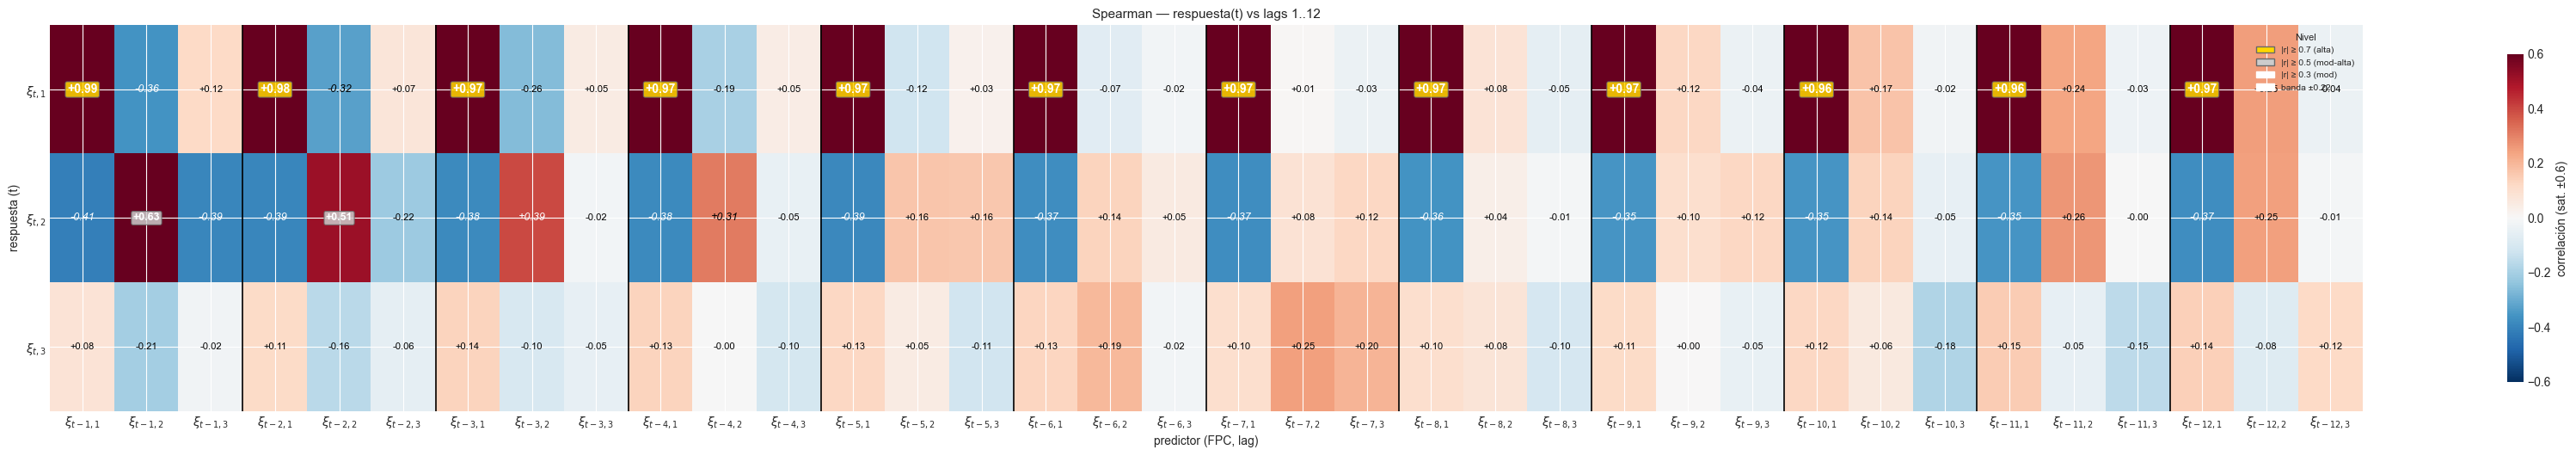

In [79]:
T_theta = SCORES_STD.shape[0]
K_total = SCORES_STD.shape[1]                                # nº de FPC disponibles (M)

# Lags de Diagnostico
N_LAGS_MAX = 12
N_LAGS_MAX = int(np.clip(N_LAGS_MAX, 1, T_theta - 2))

def _spearman_block(Y, X):
    """Spearman columna-a-columna vía rangos (pandas; sin scipy)."""
    Yr = pd.DataFrame(Y).rank().to_numpy()
    Xr = pd.DataFrame(X).rank().to_numpy()
    Yc = Yr - Yr.mean(0); Xc = Xr - Xr.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

# ── Matrices de correlación: respuesta (t) × predictor (FPC j, lag ℓ) ────────
n_cov = K_total * N_LAGS_MAX
corr_pearson  = np.zeros((K_total, n_cov))
corr_spearman = np.zeros((K_total, n_cov))
col_labels = []
y_block = SCORES_STD[N_LAGS_MAX:, :]                         # respuesta en t (alineada)

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES_STD[N_LAGS_MAX - lag : T_theta - lag, :]   # predictores en t-lag
    sp = _spearman_block(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_pearson[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_spearman[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band  = 1.96 / np.sqrt(len(y_block))                     # banda de significancia (referencia)
VCLIP = 0.6

# ── Heatmaps de correlación ───────────────────────────────────────────────────
fig = plot_rezagos_heatmap(
    corr_pearson, col_labels, row_labels,
    title=f"Pearson — respuesta(t) vs lags 1..{N_LAGS_MAX}",
    n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=VCLIP,
    save_path=str(PATHS["out_report"] / "12a_rezagos_pearson.png"),
)
plt.show()

fig = plot_rezagos_heatmap(
    corr_spearman, col_labels, row_labels,
    title=f"Spearman — respuesta(t) vs lags 1..{N_LAGS_MAX}",
    n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=VCLIP,
    save_path=str(PATHS["out_report"] / "12b_rezagos_spearman.png"),
)
plt.show()

## 4.1 Selecion de lags y DATSET final 

In [80]:
N_LAGS  = 1
T_theta = SCORES_STD.shape[0]   # [FIX] datasets sobre scores estandarizados
K_total = SCORES_STD.shape[1]   # nº de FPC disponibles (M)
T_eff   = T_theta - N_LAGS
COMPONENT_IDX = list(range(K_total)) 

print(f"K_total disponibles : {K_total}  (índices 0 … {K_total - 1})")
print(f"T_theta             : {T_theta}")
print(f"N_LAGS              : {N_LAGS}")
print(f"T_eff               : {T_eff}")

K_total disponibles : 3  (índices 0 … 2)
T_theta             : 88
N_LAGS              : 1
T_eff               : 87


In [81]:
# ── Validación ───────────────────────────────────────────────────────────────
assert len(COMPONENT_IDX) > 0, "COMPONENT_IDX no puede estar vacío."
assert len(COMPONENT_IDX) == len(set(COMPONENT_IDX)), "COMPONENT_IDX tiene índices repetidos."
assert all(0 <= i < K_total for i in COMPONENT_IDX), (
    f"Todos los índices deben estar en [0, {K_total - 1}]. Recibido: {COMPONENT_IDX}"
)

n_components = len(COMPONENT_IDX)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"K_total disponibles : {K_total}")
print(f"Componentes usados  : {n_components}  →  índices {COMPONENT_IDX}")
print(f"Orden AR (N_LAGS)   : {N_LAGS}")
print()
print(f"  {'k_modelo':>8}  {'idx_THETA':>10}  {'nombre_resp':>14}")
print(f"  {'─'*8}  {'─'*10}  {'─'*14}")
for k_model, idx in enumerate(COMPONENT_IDX):
    print(f"  {k_model:>8}  {idx:>10}  {'fpc_' + str(idx + 1):>14}")

K_total disponibles : 3
Componentes usados  : 3  →  índices [0, 1, 2]
Orden AR (N_LAGS)   : 1

  k_modelo   idx_THETA     nombre_resp
  ────────  ──────────  ──────────────
         0           0           fpc_1
         1           1           fpc_2
         2           2           fpc_3


In [82]:
# ── Construcción de DataFrames AR(p) ─────────────────────────────────────────
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]   # (T, n_components) — [FIX] scores FPCA ESTANDARIZADOS

cov_names = [
    f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
    for lag in range(1, N_LAGS + 1)
    for j in range(n_components)
]

dfs = {}
for k in range(n_components):
    y_col  = SCORES_sel[N_LAGS:, k]
    X_cols = np.hstack([
        SCORES_sel[N_LAGS - lag: T_theta - lag, :]
        for lag in range(1, N_LAGS + 1)
    ])
    resp_name = f"fpc_{COMPONENT_IDX[k] + 1}"
    dfs[k] = pd.DataFrame(
        np.column_stack([y_col, X_cols]),
        columns=[resp_name] + cov_names,
    )

manifest = {
    "scores_scale":  "standardized_zscore_ddof0",   # [FIX] contrato de escala
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "datasets":      {},
}
for k in range(n_components):
    fname = f"dataset_fpc_{COMPONENT_IDX[k] + 1}.csv"
    dfs[k].to_csv(PATHS["functional"] / fname, index=False)
    manifest["datasets"][fname] = {
        "response": f"fpc_{COMPONENT_IDX[k] + 1}",
        "shape":    list(dfs[k].shape),
    }
    print(f"  guardado {fname}  resp='fpc_{COMPONENT_IDX[k] + 1}'  shape={dfs[k].shape}")

with open(PATHS["functional"] / "datasets_manifest.json", "w", encoding="utf-8") as _f:
    json.dump(manifest, _f, indent=2, ensure_ascii=False)
print(f"[functional] {n_components} datasets + datasets_manifest.json → {PATHS['functional']}")

  guardado dataset_fpc_1.csv  resp='fpc_1'  shape=(87, 4)
  guardado dataset_fpc_2.csv  resp='fpc_2'  shape=(87, 4)
  guardado dataset_fpc_3.csv  resp='fpc_3'  shape=(87, 4)
[functional] 3 datasets + datasets_manifest.json → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\datos_nivel_3


# 5. Especificación de hiperparámetros y ajuste MCMC

In [83]:
MCMC_CONFIG = {"nsim": 2500, "burn": 500, "N": 25, "M": 50}
N_CHAINS    = 2
BURN        = int(MCMC_CONFIG["burn"])
print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS}  (réplicas que ejecutará MATLAB)")

MCMC_CONFIG : {'nsim': 2500, 'burn': 500, 'N': 25, 'M': 50}
N_CHAINS    : 2  (réplicas que ejecutará MATLAB)


In [84]:
# ════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS — priors heterogéneas por tipo de variable
# ════════════════════════════════════════════════════════════════════════════

# ── Escalares globales ────────────────────────────────────────────────────────
HP_GLOBAL = {
    "atau":  2.0,
    "btau":  0.5,
    "ag":    2.0,
    "bg":    0.5,
    "mumu":  0.0,
    "taumu": 1.0,
    "pwj":   0.5,
}

# ── Priors por tipo de variable ───────────────────────────────────────────────
#   Formato: "tipo": (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0,  0.0, 1.0),   # E[π] = 0.90
    "cross_lag": (1.0, 1.0,  0.0, 1.0),   # E[π] = 0.50
}

# ── Clasificador ──────────────────────────────────────────────────────────────
def _classify(name: str, k_model: int, component_idx: list) -> str:
    own_name = f"fpc_{component_idx[k_model] + 1}_lag1"
    if name == own_name:
        return "own_lag1"
    if "_lag" in name:
        return "cross_lag"
    return "cross_lag"   # fallback: cualquier variable no reconocida → débil

# ── Construcción automática de HYPERPARAMS_LIST ───────────────────────────────
HYPERPARAMS_LIST = []
for k in range(n_components):
    p = len(cov_names)
    apij    = np.empty(p); bpij    = np.empty(p)
    mupsij  = np.empty(p); taupsij = np.empty(p)

    for j, name in enumerate(cov_names):
        vtype              = _classify(name, k, COMPONENT_IDX)
        a, b, mu, tau      = HP_BY_TYPE[vtype]
        apij[j]    = a;    bpij[j]    = b
        mupsij[j]  = mu;   taupsij[j] = tau

    HYPERPARAMS_LIST.append({**HP_GLOBAL,
                              "apij": apij,     "bpij": bpij,
                              "mupsij": mupsij, "taupsij": taupsij})

# ── Tabla de resumen ──────────────────────────────────────────────────────────
_W = 70
print("═" * _W)
print(f"  HYPERPARAMS_LIST  —  {n_components} componentes × {p} variables")
print("═" * _W)
print(f"  Globales: atau={HP_GLOBAL['atau']} btau={HP_GLOBAL['btau']}  "
      f"ag={HP_GLOBAL['ag']} bg={HP_GLOBAL['bg']}  "
      f"mumu={HP_GLOBAL['mumu']} taumu={HP_GLOBAL['taumu']}  "
      f"pwj={HP_GLOBAL['pwj']}")
print()
for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"  Componente k={k+1}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'Variable':<26} {'Tipo':<12} {'apij':>6} {'bpij':>6} "
          f"{'E[π]':>6} {'mupsij':>8} {'taupsij':>9}")
    print(f"  {'─'*26} {'─'*12} {'─'*6} {'─'*6} "
          f"{'─'*6} {'─'*8} {'─'*9}")
    for j, name in enumerate(cov_names):
        vtype = _classify(name, k, COMPONENT_IDX)
        a  = hp["apij"][j];    b  = hp["bpij"][j]
        mu = hp["mupsij"][j];  tau = hp["taupsij"][j]
        e_pi = a / (a + b)
        marker = "  ◄" if vtype == "own_lag1" else ""
        print(f"  {name:<26} {vtype:<12} {a:>6.1f} {b:>6.1f} "
              f"{e_pi:>6.3f} {mu:>8.1f} {tau:>9.1f}{marker}")
    print()

══════════════════════════════════════════════════════════════════════
  HYPERPARAMS_LIST  —  3 componentes × 3 variables
══════════════════════════════════════════════════════════════════════
  Globales: atau=2.0 btau=0.5  ag=2.0 bg=0.5  mumu=0.0 taumu=1.0  pwj=0.5

  Componente k=1  (fpc_1)
  Variable                   Tipo           apij   bpij   E[π]   mupsij   taupsij
  ────────────────────────── ──────────── ────── ────── ────── ──────── ─────────
  fpc_1_lag1                 own_lag1        9.0    1.0  0.900      0.0       1.0  ◄
  fpc_2_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_3_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0

  Componente k=2  (fpc_2)
  Variable                   Tipo           apij   bpij   E[π]   mupsij   taupsij
  ────────────────────────── ──────────── ────── ────── ────── ──────── ─────────
  fpc_1_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_2_lag1        

In [85]:
# ── Guardar hiperparámetros del modelo en artefact ───────────────────────────
filepath_hyperparams = PATHS["out_artefact"] / "hyperparameters.json"

hp_artifact = {
    "global": HP_GLOBAL,
    "by_type": HP_BY_TYPE,
    "mcmc_config": MCMC_CONFIG,
    "n_iter": N_CHAINS,
    # [FIX] esquema real de semillas usado por psbp_fd_iteracion.m
    "seed_scheme": "SEED_BASE + tt*9973 + k*31",
    "seed_base": SEED,
    "scores_scale": "standardized_zscore_ddof0",
    "hyperparams_list": []
}

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k].copy()
    hp_artifact["hyperparams_list"].append({
        "component_k": k,
        "fpc_idx": int(COMPONENT_IDX[k] + 1),
        "hyperparams": {
            key: value.tolist() if isinstance(value, np.ndarray) else value
            for key, value in hp.items()
        }
    })

with open(filepath_hyperparams, "w", encoding="utf-8") as f:
    json.dump(hp_artifact, f, indent=2, ensure_ascii=False)

print(f"✓ Hiperparámetros guardados en: {filepath_hyperparams}")

✓ Hiperparámetros guardados en: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\datos_nivel_3\hyperparameters.json
